In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import roc_curve, auc

In [2]:
# Load the ML-ready dataset
df = pd.read_csv('ml_ready_with_features.csv', sep=';')

print(f"Dataset shape: {df.shape}")
print(f"\nColumn names:")
print(df.columns.tolist())
print(f"\nFirst few rows:")
df.head()

Dataset shape: (9161, 19)

Column names:
['id', 'Title', 'Artists', 'Danceability', 'Energy', 'Loudness', 'Speechiness', 'Acousticness', 'Instrumentalness', 'Valence', '# of Artist', '# of Nationality', 'Loudness_norm', 'best_rank', 'weeks_on_chart', 'peak_score', 'longevity_score', 'popularity_score', 'popularity_label']

First few rows:


,id,Title,Artists,Danceability,Energy,Loudness,Speechiness,Acousticness,Instrumentalness,Valence,# of Artist,# of Nationality,Loudness_norm,best_rank,weeks_on_chart,peak_score,longevity_score,popularity_score,popularity_label
0,000xQL6tZNLJzIrtIgxqSl,Still Got Time (feat. PARTYNEXTDOOR),ZAYN,0.748,0.627,-6.029,0.064,0.131,0.0,0.524,Artist 1,Nationality 1,0.825120,40,118,80.5,100.0,80.25,Popular
1,003VDDA7J3Xb2ZFlNx7nIZ,YELL OH,"Trippie Redd, Young Thug",0.842,0.578,-6.050,0.138,0.004,0.0,0.190,Artist 1,Nationality 1,0.824511,108,2,46.5,10.0,27.25,Not Popular
2,003eoIwxETJujVWmNFMoZy,Growing Pains,Alessia Cara,0.353,0.755,-6.276,0.733,0.082,0.0,0.437,Artist 1,Nationality 1,0.817955,91,14,55.0,70.0,55.50,Not Popular
3,003vvx7Niy0yvhvHt4a68B,Mr. Brightside,The Killers,0.352,0.911,-5.230,0.075,0.001,0.0,0.236,Artist 1,Nationality 1,0.848296,73,560,64.0,100.0,72.00,Popular
4,00B7TZ0Xawar6NZ00JFomN,Best Life (feat. Chance The Rapper),Cardi B,0.620,0.625,-7.438,0.553,0.287,0.0,0.665,Artist 1,Nationality 1,0.784249,61,14,70.0,70.0,63.00,Not Popular


In [3]:
# Set pandas display options to show full output
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

# Check for missing values
print("Missing values:")
print(df.isnull().sum())


# Basic statistics
print(f"\nFeature statistics:")
df.describe()

Missing values:
id                  0
Title               0
Artists             0
Danceability        0
Energy              0
Loudness            0
Speechiness         0
Acousticness        0
Instrumentalness    0
Valence             0
# of Artist         0
# of Nationality    0
Loudness_norm       0
best_rank           0
weeks_on_chart      0
peak_score          0
longevity_score     0
popularity_score    0
popularity_label    0
dtype: int64

Feature statistics:


,Danceability,Energy,Loudness,Speechiness,Acousticness,Instrumentalness,Valence,Loudness_norm,best_rank,weeks_on_chart,peak_score,longevity_score,popularity_score
count,9161.000000,9161.000000,9161.000000,9161.000000,9161.000000,9161.000000,9161.000000,9161.000000,9161.000000,9161.000000,9161.00000,9161.000000,9161.000000
mean,0.674146,0.636076,-6.465501,0.128299,0.234024,0.013770,0.486465,0.812458,87.258160,50.983626,56.87092,51.429975,49.007450
std,0.147904,0.170402,2.641113,0.117881,0.248563,0.082544,0.226281,0.076610,58.544799,120.342609,29.27240,41.295436,28.067511
min,0.073000,0.005000,-34.475000,0.022000,0.000000,0.000000,0.026000,0.000000,1.000000,1.000000,0.50000,5.000000,2.250000
25%,0.581000,0.532000,-7.638000,0.044000,0.040000,0.000000,0.310000,0.778448,35.000000,2.000000,33.00000,10.000000,23.000000
50%,0.691000,0.651000,-6.063000,0.076000,0.139000,0.000000,0.482000,0.824133,81.000000,8.000000,60.00000,40.000000,49.750000
75%,0.782000,0.761000,-4.731000,0.180000,0.351000,0.000000,0.660000,0.862770,135.000000,44.000000,83.00000,100.000000,75.750000
max,0.985000,0.996000,0.000000,0.966000,0.994000,0.956000,0.982000,1.000000,200.000000,2251.000000,100.00000,100.000000,90.000000


In [4]:
# Check label distribution - cleaner output
print(f"\n{'='*50}")
print("LABEL DISTRIBUTION")
print('='*50)

# Counts
print("\nCounts:")
for label, count in df['popularity_label'].value_counts().items():
    print(f"  {label:15s}: {count:,}")

# Percentages
print("\nPercentages:")
for label, pct in (df['popularity_label'].value_counts(normalize=True) * 100).items():
    print(f"  {label:15s}: {pct:.2f}%")

print(f"\nTotal songs: {len(df):,}")
print('='*50)


LABEL DISTRIBUTION

Counts:
  Not Popular    : 6,391
  Popular        : 2,770

Percentages:
  Not Popular    : 69.76%
  Popular        : 30.24%

Total songs: 9,161


In [5]:
# Load original chart data to calculate artist features
df_charts = pd.read_csv('final_cleaned_data.csv', delimiter=';')
df_charts['Date'] = pd.to_datetime(df_charts['Date'])

# Check column names first
print("Columns in df_charts:")
print(df_charts.columns.tolist())
print("\nFirst few rows:")
print(df_charts.head())

Columns in df_charts:
['Rank', 'Title', 'Artists', 'Date', 'Danceability', 'Energy', 'Loudness', 'Speechiness', 'Acousticness', 'Instrumentalness', 'Valence', '# of Artist', 'Artist (Ind.)', '# of Nationality', 'Nationality', 'Continent', 'Points (Total)', 'Points (Ind for each Artist/Nat)', 'id', 'Song URL', 'Loudness_norm']

First few rows:
   Rank              Title                     Artists       Date  \
0     1    Ella Baila Sola  Eslabon Armado, Peso Pluma 2023-05-29   
1     2     WHERE SHE GOES                   Bad Bunny 2023-05-29   
2     3    La Bebe - Remix       Yng Lvcas, Peso Pluma 2023-05-29   
3     4  Cupid - Twin Ver.                 FIFTY FIFTY 2023-05-29   
4     5          un x100to   Grupo Frontera, Bad Bunny 2023-05-29   

   Danceability  Energy  Loudness  Speechiness  Acousticness  \
0         0.668   0.758    -5.176        0.033         0.483   
1         0.652   0.800    -4.019        0.061         0.143   
2         0.812   0.479    -5.678        0.333  

In [6]:
# Load original chart data to calculate artist features
df_charts = pd.read_csv('final_cleaned_data.csv', delimiter=';')
df_charts['Date'] = pd.to_datetime(df_charts['Date'])

# Calculate artist features
artist_features = df_charts.groupby('Artist (Ind.)').agg({
    'Rank': ['mean', 'min', 'count'],
    'Date': ['min', 'max'],
    'Title': 'nunique'
}).reset_index()

# Flatten column names
artist_features.columns = ['artist', 'avg_rank', 'best_rank', 'total_appearances',
                           'first_appearance', 'last_appearance', 'unique_songs']

# Calculate derived features
artist_features['years_active'] = (
    (artist_features['last_appearance'] - artist_features['first_appearance']).dt.days / 365
).replace(0, 0.01)  # Avoid division by zero

artist_features['songs_per_year'] = (
    artist_features['unique_songs'] / artist_features['years_active']
)

artist_features['avg_rank_score'] = (201 - artist_features['avg_rank']) / 200

# Hit rate: What % of artist's songs reached top 50?
top50_songs = df_charts[df_charts['Rank'] <= 50].groupby('Artist (Ind.)')['Title'].nunique()
artist_features['hit_rate'] = (
    top50_songs / artist_features['unique_songs']
).fillna(0)

# Is the artist currently active?
latest_date = df_charts['Date'].max()
artist_features['is_recently_active'] = (
    (latest_date - artist_features['last_appearance']).dt.days < 180
).astype(int)

print("Artist features created!")
print(f"Total artists: {len(artist_features)}")
print(f"\nArtist features summary:")
print(artist_features[['artist', 'avg_rank_score', 'hit_rate', 'years_active', 
                        'songs_per_year', 'total_appearances']].head(10))

Artist features created!
Total artists: 1507

Artist features summary:
              artist  avg_rank_score  hit_rate  years_active  songs_per_year  \
0               $NOT        0.390714       0.0      0.016438       60.833333   
1        $uicideboy$        0.340500       0.0      0.153425        6.517857   
2           (G)I-DLE        0.284455       0.0      1.205479        2.488636   
3             *NSYNC        0.379655       0.0      5.008219        0.199672   
4        13 Organisé        0.203529       0.0      0.043836       22.812500   
5  187 Strassenbande        0.167143       0.0      3.843836        1.300784   
6           2 Chainz        0.350702       0.0      1.758904        3.979751   
7          21 Savage        0.499996       0.0      5.857534        8.194574   
8          22 Savage        0.105417       0.0      0.030137       33.181818   
9           24kGoldn        0.643228       0.0      2.589041        1.931217   

   total_appearances  
0                  7  
1 

In [7]:
# For multi-artist songs, we'll use the LEAD artist's features
# Extract first artist from the Artists column
df['lead_artist'] = df['Artists'].str.split(',').str[0].str.strip()

# Merge artist features
df_enhanced = df.merge(
    artist_features[['artist', 'avg_rank_score', 'hit_rate', 'years_active', 
                     'songs_per_year', 'is_recently_active', 'total_appearances']],
    left_on='lead_artist',
    right_on='artist',
    how='left'
)

# Fill missing values with median (for new/unknown artists)
artist_cols = ['avg_rank_score', 'hit_rate', 'years_active', 
               'songs_per_year', 'is_recently_active', 'total_appearances']

for col in artist_cols:
    df_enhanced[col] = df_enhanced[col].fillna(df_enhanced[col].median())

print(f"Enhanced dataset shape: {df_enhanced.shape}")
print(f"\nNew artist features added: {artist_cols}")

Enhanced dataset shape: (9161, 27)

New artist features added: ['avg_rank_score', 'hit_rate', 'years_active', 'songs_per_year', 'is_recently_active', 'total_appearances']


In [8]:
# Create engineered features - Audio Interactions on the ENHANCED dataframe
df_enhanced['dance_potential'] = df_enhanced['Energy'] * df_enhanced['Danceability']
df_enhanced['feel_good_score'] = df_enhanced['Valence'] * df_enhanced['Energy']
df_enhanced['chill_score'] = df_enhanced['Acousticness'] * (1 - df_enhanced['Energy'])
df_enhanced['party_score'] = 0.4 * df_enhanced['Energy'] + 0.4 * df_enhanced['Danceability'] + 0.2 * df_enhanced['Valence']

print("✓ Audio interaction features created successfully!")
print(f"\nNew features preview:")
print(df_enhanced[['dance_potential', 'feel_good_score', 'chill_score', 'party_score']].describe())

✓ Audio interaction features created successfully!

New features preview:
       dance_potential  feel_good_score  chill_score  party_score
count      9161.000000      9161.000000  9161.000000  9161.000000
mean          0.432021         0.323782     0.107706     0.621382
std           0.146726         0.190431     0.161570     0.123604
min           0.001022         0.000518     0.000000     0.042200
25%           0.341044         0.172032     0.010669     0.551800
50%           0.443275         0.302286     0.041184     0.635600
75%           0.535806         0.455112     0.124683     0.708800
max           0.870610         0.939910     0.965294     0.928000


In [9]:
# ============================================
# TEMPORAL FEATURES
# ============================================

# For each song, get first appearance date from chart data
song_first_date = df_charts.groupby('Title')['Date'].min().reset_index()
song_first_date.columns = ['Title', 'release_date']

# Extract temporal features
song_first_date['release_month'] = song_first_date['release_date'].dt.month
song_first_date['release_quarter'] = song_first_date['release_date'].dt.quarter
song_first_date['release_year'] = song_first_date['release_date'].dt.year
song_first_date['release_day_of_week'] = song_first_date['release_date'].dt.dayofweek

# Strategic release timing
song_first_date['is_holiday_season'] = (
    song_first_date['release_month'].isin([11, 12])
).astype(int)

song_first_date['is_summer'] = (
    song_first_date['release_month'].isin([6, 7, 8])
).astype(int)

song_first_date['is_friday_release'] = (
    song_first_date['release_day_of_week'] == 4
).astype(int)

# Days since release
latest_date = df_charts['Date'].max()
song_first_date['days_since_release'] = (
    (latest_date - song_first_date['release_date']).dt.days
)

print("✓ Temporal features created!")
print(f"Total songs with temporal data: {len(song_first_date)}")
print(f"\nTemporal features preview:")
print(song_first_date[['Title', 'release_month', 'is_holiday_season', 
                        'is_summer', 'is_friday_release', 'days_since_release']].head(10))

✓ Temporal features created!
Total songs with temporal data: 7440

Temporal features preview:
                                                          Title  \
0                                                    '98 Braves   
1                                                             !   
2                                           #PROUDCATOWNERREMIX   
3                                                           $$$   
4                                                  $€ Freestyle   
5                                              'Till I Collapse   
6                                          'tis the damn season   
7                                       (Don't Fear) The Reaper   
8                                        (Fuck A) Silver Lining   
9  (There's No Place Like) Home for the Holidays - 1959 Version   

   release_month  is_holiday_season  is_summer  is_friday_release  \
0              3                  0          0                  1   
1              8              

In [10]:
# Merge temporal features with enhanced dataset
df_enhanced = df_enhanced.merge(
    song_first_date[['Title', 'release_month', 'release_quarter', 'is_holiday_season',
                     'is_summer', 'is_friday_release', 'days_since_release']],
    on='Title',
    how='left'
)

# Fill missing values
temporal_cols = ['release_month', 'release_quarter', 'is_holiday_season',
                 'is_summer', 'is_friday_release', 'days_since_release']

for col in temporal_cols:
    if col in ['is_holiday_season', 'is_summer', 'is_friday_release']:
        df_enhanced[col] = df_enhanced[col].fillna(0).astype(int)
    else:
        df_enhanced[col] = df_enhanced[col].fillna(df_enhanced[col].median())

print(f"✓ Temporal features merged!")
print(f"Enhanced dataset shape: {df_enhanced.shape}")
print(f"\nMissing values check:")
print(df_enhanced[temporal_cols].isnull().sum())

✓ Temporal features merged!
Enhanced dataset shape: (9161, 37)

Missing values check:
release_month         0
release_quarter       0
is_holiday_season     0
is_summer             0
is_friday_release     0
days_since_release    0
dtype: int64


In [11]:
# Verify temporal features distribution
print("\n" + "="*60)
print("TEMPORAL FEATURES DISTRIBUTION")
print("="*60)

print(f"\nRelease Month:")
print(df_enhanced['release_month'].value_counts().sort_index())

print(f"\nHoliday Season Releases: {df_enhanced['is_holiday_season'].sum()} ({df_enhanced['is_holiday_season'].mean()*100:.1f}%)")
print(f"Summer Releases: {df_enhanced['is_summer'].sum()} ({df_enhanced['is_summer'].mean()*100:.1f}%)")
print(f"Friday Releases: {df_enhanced['is_friday_release'].sum()} ({df_enhanced['is_friday_release'].mean()*100:.1f}%)")

print(f"\nDays Since Release:")
print(df_enhanced['days_since_release'].describe())


TEMPORAL FEATURES DISTRIBUTION

Release Month:
release_month
1     975
2     695
3     826
4     731
5     921
6     683
7     730
8     728
9     643
10    695
11    724
12    810
Name: count, dtype: int64

Holiday Season Releases: 1534 (16.7%)
Summer Releases: 2141 (23.4%)
Friday Releases: 5911 (64.5%)

Days Since Release:
count    9161.000000
mean     1282.414693
std       664.848198
min         1.000000
25%       722.000000
50%      1309.000000
75%      1856.000000
max      2339.000000
Name: days_since_release, dtype: float64


In [57]:
# Define feature columns - ALL FEATURES COMBINED
feature_columns = [
    # Audio features (7)
    'Danceability', 
    'Energy', 
    'Speechiness', 
    'Acousticness', 
    'Instrumentalness', 
    'Valence', 
    'Loudness_norm',
    
    # Artist features (6)
    'avg_rank_score',
    'hit_rate',
    'years_active',
    'songs_per_year',
    'is_recently_active',
    'total_appearances',
    
    # Audio interaction features (4)
    'dance_potential',
    'feel_good_score',
    'chill_score',
    'party_score',
    
    # Temporal features (6)
    'release_month',
    'release_quarter',
    'is_holiday_season',
    'is_summer',
    'is_friday_release',
    'days_since_release'
]

# Separate features (X) and target (y)
X = df_enhanced[feature_columns]
y = df_enhanced['popularity_label']

print(f"Features shape: {X.shape}")
print(f"Total features: {len(feature_columns)}")
print(f"\n{'='*60}")
print("FEATURE SUMMARY")
print('='*60)
print(f"Audio features:        7")
print(f"Artist features:       6")
print(f"Audio interactions:    4")
print(f"Temporal features:     6")
print(f"{'='*60}")
print(f"TOTAL FEATURES:       {len(feature_columns)}")
print('='*60)
print(f"\nTarget values: {y.unique()}")

Features shape: (9161, 23)
Total features: 23

FEATURE SUMMARY
Audio features:        7
Artist features:       6
Audio interactions:    4
Temporal features:     6
TOTAL FEATURES:       23

Target values: ['Popular' 'Not Popular']


In [58]:
# Split data: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  # Keep same proportion of labels in train/test
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"\nTraining label distribution:")
print(y_train.value_counts())
print(f"\nTest label distribution:")
print(y_test.value_counts())

Training set size: 7328
Test set size: 1833

Training label distribution:
popularity_label
Not Popular    5112
Popular        2216
Name: count, dtype: int64

Test label distribution:
popularity_label
Not Popular    1279
Popular         554
Name: count, dtype: int64


In [59]:
# Standardize features (mean=0, std=1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully!")
print(f"\nOriginal feature ranges:")
print(X_train.describe().loc[['min', 'max']])
print(f"\nScaled feature ranges:")
print(pd.DataFrame(X_train_scaled, columns=feature_columns).describe().loc[['min', 'max']])

Features scaled successfully!

Original feature ranges:
     Danceability  Energy  Speechiness  Acousticness  Instrumentalness  \
min         0.073   0.005        0.022         0.000             0.000   
max         0.985   0.996        0.920         0.992             0.956   

     Valence  Loudness_norm  avg_rank_score  hit_rate  years_active  \
min    0.026       0.096157        0.005000       0.0      0.002740   
max    0.978       1.000000        0.894231       0.0      6.408219   

     songs_per_year  is_recently_active  total_appearances  dance_potential  \
min        0.162946                 0.0                1.0         0.001022   
max     1825.000000                 1.0            12384.0         0.870610   

     feel_good_score  chill_score  party_score  release_month  \
min         0.000518     0.000000       0.0422            1.0   
max         0.939910     0.965294       0.9280           12.0   

     release_quarter  is_holiday_season  is_summer  is_friday_release  \


In [60]:
from sklearn.preprocessing import LabelEncoder

# Encode labels to numeric values
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split data with encoded labels
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_encoded
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"\nLabel encoding:")
for i, label in enumerate(label_encoder.classes_):
    print(f"  {label} → {i}")
print(f"\nTraining label distribution:")
print(pd.Series(y_train).value_counts())
print(f"\nTest label distribution:")
print(pd.Series(y_test).value_counts())

Training set size: 7328
Test set size: 1833

Label encoding:
  Not Popular → 0
  Popular → 1

Training label distribution:
0    5112
1    2216
Name: count, dtype: int64

Test label distribution:
0    1279
1     554
Name: count, dtype: int64


In [61]:
# Dictionary to store models and their results
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=42, n_estimators=100),
    'XGBoost': XGBClassifier(scale_pos_weight=(len(y_train[y_train==0])/len(y_train[y_train==1])), 
                             random_state=42, eval_metric='logloss'),
    'SVM': SVC(class_weight='balanced', random_state=42, probability=True),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes': GaussianNB()
}

results = {}

print("Training models...\n")
print("="*70)

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    # Train the model
    model.fit(X_train_scaled, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, 'predict_proba') else None
    
    # Calculate metrics (use pos_label=1 for encoded 'Popular')
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, pos_label=1)
    
    # Calculate ROC-AUC score (only if probability predictions available)
    if y_pred_proba is not None:
        roc_auc = roc_auc_score(y_test, y_pred_proba)
    else:
        roc_auc = None
    
    # Store results
    results[name] = {
        'accuracy': accuracy,
        'f1_score': f1,
        'roc_auc': roc_auc,
        'predictions': y_pred,
        'probabilities': y_pred_proba
    }
    
    print(f"  ✓ Accuracy: {accuracy:.4f}")
    print(f"  ✓ F1-Score: {f1:.4f}")
    if roc_auc is not None:
        print(f"  ✓ ROC-AUC:  {roc_auc:.4f}")

print("\n" + "="*70)
print("All models trained successfully!")

Training models...


Training Logistic Regression...
  ✓ Accuracy: 0.6787
  ✓ F1-Score: 0.5837
  ✓ ROC-AUC:  0.7682

Training Random Forest...
  ✓ Accuracy: 0.7436
  ✓ F1-Score: 0.5084
  ✓ ROC-AUC:  0.7747

Training XGBoost...
  ✓ Accuracy: 0.7278
  ✓ F1-Score: 0.5906
  ✓ ROC-AUC:  0.7860

Training SVM...
  ✓ Accuracy: 0.6732
  ✓ F1-Score: 0.5950
  ✓ ROC-AUC:  0.7681

Training KNN...
  ✓ Accuracy: 0.6983
  ✓ F1-Score: 0.4487
  ✓ ROC-AUC:  0.7046

Training Naive Bayes...
  ✓ Accuracy: 0.5095
  ✓ F1-Score: 0.5271
  ✓ ROC-AUC:  0.6911

All models trained successfully!



MODEL PERFORMANCE COMPARISON
              Model  Accuracy  F1-Score  ROC-AUC
                SVM  0.673213  0.594997 0.768077
            XGBoost  0.727769  0.590648 0.786045
Logistic Regression  0.678669  0.583746 0.768154
        Naive Bayes  0.509547  0.527091 0.691061
      Random Forest  0.743590  0.508368 0.774660
                KNN  0.698309  0.448654 0.704639


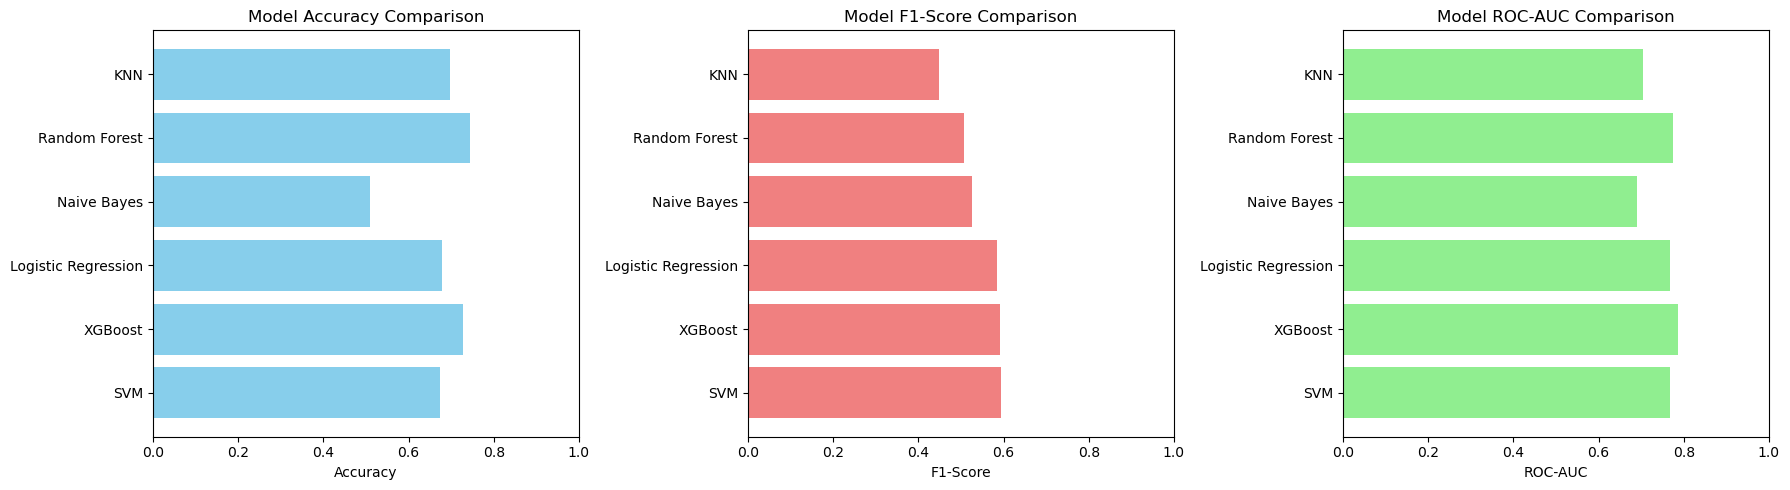

In [62]:
# Create comparison dataframe with ROC-AUC
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[m]['accuracy'] for m in results.keys()],
    'F1-Score': [results[m]['f1_score'] for m in results.keys()],
    'ROC-AUC': [results[m]['roc_auc'] if results[m]['roc_auc'] is not None else 0 
                for m in results.keys()]
})

comparison_df = comparison_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)

print("\n" + "="*70)
print("MODEL PERFORMANCE COMPARISON")
print("="*70)
print(comparison_df.to_string(index=False))
print("="*70)

# Visualize comparison with ROC-AUC
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Accuracy comparison
axes[0].barh(comparison_df['Model'], comparison_df['Accuracy'], color='skyblue')
axes[0].set_xlabel('Accuracy')
axes[0].set_title('Model Accuracy Comparison')
axes[0].set_xlim([0, 1])

# F1-Score comparison
axes[1].barh(comparison_df['Model'], comparison_df['F1-Score'], color='lightcoral')
axes[1].set_xlabel('F1-Score')
axes[1].set_title('Model F1-Score Comparison')
axes[1].set_xlim([0, 1])

# ROC-AUC comparison
axes[2].barh(comparison_df['Model'], comparison_df['ROC-AUC'], color='lightgreen')
axes[2].set_xlabel('ROC-AUC')
axes[2].set_title('Model ROC-AUC Comparison')
axes[2].set_xlim([0, 1])

plt.tight_layout()
plt.show()

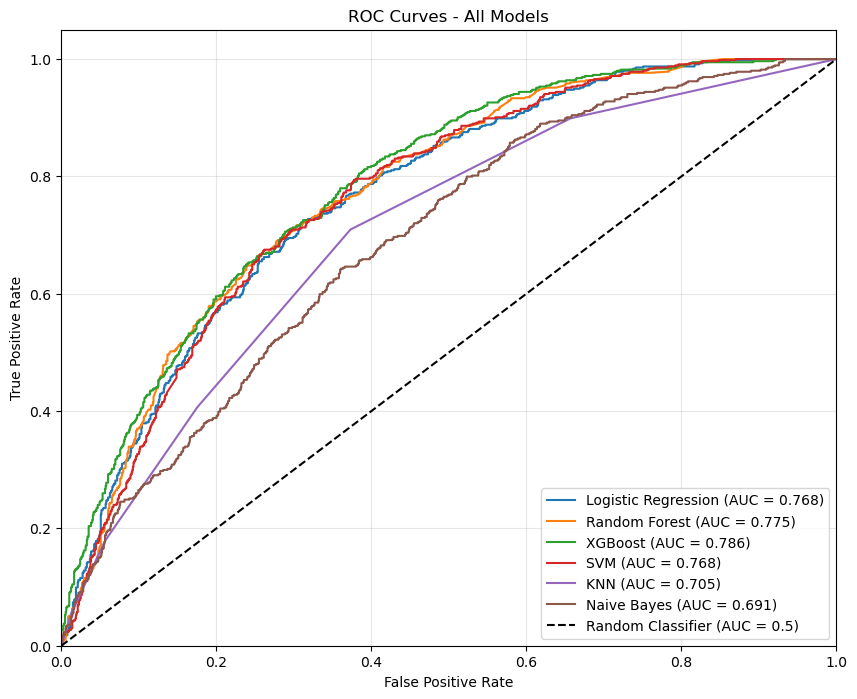

In [63]:
# Plot ROC Curves for all models
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 8))

for name in results.keys():
    if results[name]['probabilities'] is not None:
        fpr, tpr, _ = roc_curve(y_test, results[name]['probabilities'])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - All Models')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()


DETAILED EVALUATION: SVM

Classification Report:
              precision    recall  f1-score   support

 Not Popular       0.87      0.62      0.73      1279
     Popular       0.48      0.79      0.59       554

    accuracy                           0.67      1833
   macro avg       0.68      0.71      0.66      1833
weighted avg       0.75      0.67      0.69      1833


All Metrics:
  Accuracy: 0.6732
  F1-Score: 0.5950
  ROC-AUC:  0.7681


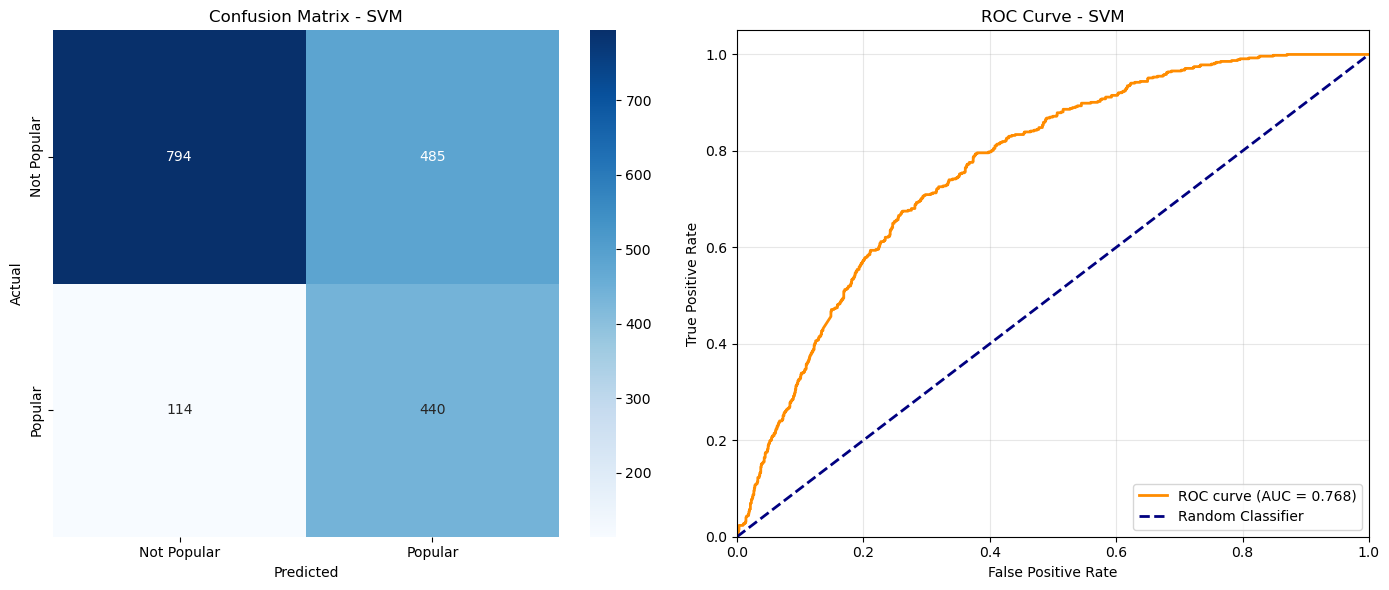

In [64]:
# Get best model based on F1-score
best_model_name = comparison_df.iloc[0]['Model']
best_predictions = results[best_model_name]['predictions']
best_probabilities = results[best_model_name]['probabilities']

print(f"\n{'='*70}")
print(f"DETAILED EVALUATION: {best_model_name}")
print('='*70)

# Classification report (with target names for better readability)
print("\nClassification Report:")
print(classification_report(y_test, best_predictions, 
                           target_names=['Not Popular', 'Popular']))

# All metrics
print(f"\nAll Metrics:")
print(f"  Accuracy: {results[best_model_name]['accuracy']:.4f}")
print(f"  F1-Score: {results[best_model_name]['f1_score']:.4f}")
if results[best_model_name]['roc_auc'] is not None:
    print(f"  ROC-AUC:  {results[best_model_name]['roc_auc']:.4f}")

# Confusion matrix (use numeric labels)
cm = confusion_matrix(y_test, best_predictions, labels=[0, 1])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Popular', 'Popular'],
            yticklabels=['Not Popular', 'Popular'],
            ax=axes[0])
axes[0].set_title(f'Confusion Matrix - {best_model_name}')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ROC Curve for best model
if best_probabilities is not None:
    fpr, tpr, _ = roc_curve(y_test, best_probabilities)
    roc_auc = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, color='darkorange', lw=2, 
                 label=f'ROC curve (AUC = {roc_auc:.3f})')
    axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', 
                 label='Random Classifier')
    axes[1].set_xlim([0.0, 1.0])
    axes[1].set_ylim([0.0, 1.05])
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title(f'ROC Curve - {best_model_name}')
    axes[1].legend(loc="lower right")
    axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()